# Action-Angle Coordinates with JAX and PyTorch

This notebook describes how to compute action-angle coordinates with
[JAX](https://docs.jax.dev/) and [PyTorch](https://pytorch.org/) and how to
differentiate them with respect to the phase-space coordinates and with
respect to the parameters of the potential. All of `galpy.actionAngle` runs
on the backends, except for `actionAngleTorus`, which interfaces with the
external Torus Mapper code. See the [quick start](../getting_started/backends.ipynb) for an
introduction to galpy's backends and the [action-angle
introduction](introduction.ipynb) for the methods
themselves.

The interface is unchanged: an `actionAngle` object is set up for a
potential and called with phase-space coordinates, through `__call__` for
the actions, `actionsFreqs` for the actions and frequencies, and
`actionsFreqsAngles` for all three. A call with JAX arrays or PyTorch tensors,
or with a potential that has a backend parameter, computes with that
backend.

Action-angle calculations consist of many small array operations (root
finding, quadrature, ...). In eager JAX each of these is dispatched
separately, which makes eager JAX slow for these calculations; eager
PyTorch has a much smaller overhead per operation. Below, we therefore use
PyTorch eagerly and compile the JAX calculations with `jax.jit`.

In [1]:
%matplotlib inline
import time

import jax

jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy
import torch

from galpy.actionAngle import (
    actionAngleAdiabatic,
    actionAngleIsochrone,
    actionAngleIsochroneApprox,
    actionAngleSpherical,
    actionAngleStaeckel,
    actionAngleVerticalInverse,
    estimateDeltaStaeckel,
)
from galpy.orbit import Orbit
from galpy.potential import (
    IsochronePotential,
    IsothermalDiskPotential,
    LogarithmicHaloPotential,
    MiyamotoNagaiPotential,
    MWPotential2014,
)

# Three phase-space points (R,vR,vT,z,vz) as NumPy, JAX, and PyTorch arrays
wn = [
    numpy.array([1.0, 0.9, 1.1]),
    numpy.array([0.1, -0.05, 0.02]),
    numpy.array([1.0, 1.05, 0.95]),
    numpy.array([0.05, 0.1, -0.02]),
    numpy.array([0.05, 0.02, 0.08]),
]
wj = [jnp.asarray(x) for x in wn]
wt = [torch.as_tensor(x) for x in wn]

## The Staeckel approximation

`actionAngleStaeckel` has two implementations, a vectorized Python
implementation (`c=False`) and a C implementation (`c=True`), which behave
differently on the backends.

### `c=False`

The Python implementation runs entirely in JAX or PyTorch and is
differentiable with respect to the phase-space coordinates and the
parameters of the potential. With PyTorch tensors:

In [2]:
aAS = actionAngleStaeckel(pot=MWPotential2014, delta=0.45, c=False)
jr, lz, jz = aAS(*wt)
print(jr, jz)
print(aAS(*wn)[0])

tensor([0.0040, 0.0033, 0.0013], dtype=torch.float64) tensor([0.0033, 0.0110, 0.0020], dtype=torch.float64)
[0.00396151 0.00325739 0.00133077]


To differentiate with respect to a parameter of the potential, set up the
potential, and the `actionAngle` object, with that parameter as a tensor
that requires a gradient. For the scale length of a Miyamoto-Nagai disk:

In [3]:
a = torch.tensor(0.5, dtype=torch.float64, requires_grad=True)
aAS_mn = actionAngleStaeckel(pot=MiyamotoNagaiPotential(a=a, b=0.3), delta=0.4, c=False)
aAS_mn(*wt)[0].sum().backward()
print(a.grad)

tensor(2.1363, dtype=torch.float64)


With JAX, set up the potential inside the function that is differentiated;
compiling with `jax.jit` makes this fast:

In [4]:
def jr_of_a(a):
    aAS = actionAngleStaeckel(
        pot=MiyamotoNagaiPotential(a=a, b=0.3), delta=0.4, c=False
    )
    return aAS(*wj)[0].sum()


djr_da = jax.jit(jax.grad(jr_of_a))
print(djr_da(0.5))

2.1363334492980144


The derivative agrees with a finite difference in which the potential and
the `actionAngle` object are rebuilt:

In [5]:
def jr_of_a_numpy(a):
    aAS = actionAngleStaeckel(
        pot=MiyamotoNagaiPotential(a=a, b=0.3), delta=0.4, c=False
    )
    return numpy.sum(aAS(*wn)[0])


h = 1e-4
print((jr_of_a_numpy(0.5 + h) - jr_of_a_numpy(0.5 - h)) / (2.0 * h))

2.1363334709290083


The derivative of an action integral is of first order only (second
derivatives of the actions are not supported).

### `c=True`

The C implementation is much faster for small numbers of points. On a
backend, the C code computes the actions, frequencies, and angles together
with their Jacobian with respect to the phase-space coordinates, and galpy
attaches this Jacobian to the result as a custom derivative. A derivative
through a `c=True` call therefore costs one C call, also under `jax.jit`:

In [6]:
aASc = actionAngleStaeckel(pot=MWPotential2014, delta=0.45, c=True)


def total_jr(R):
    return aASc(R, *wj[1:])[0].sum()


print(jax.jit(jax.grad(total_jr))(wj[0]))

[ 0.00586234  0.01025081 -0.00485871]


It agrees with the derivative of the `c=False` implementation by automatic
differentiation, here with PyTorch:

In [7]:
Rt = wt[0].clone().requires_grad_(True)
aAS(Rt, *wt[1:])[0].sum().backward()
print(Rt.grad)

tensor([ 0.0059,  0.0103, -0.0049], dtype=torch.float64)


The `c=True` path gives derivatives with respect to the phase-space
coordinates only, to first order, with a fixed focal length `delta`;
derivatives with respect to the parameters of the potential require
`c=False`.

### Estimating the focal length

`estimateDeltaStaeckel` also runs on the backends. Together with an orbit
integrated in JAX, it can be part of a compiled function that integrates an
orbit, estimates the focal length along it, and computes the actions along
the orbit:

First call (compiles): 36.4 s


Second call: 0.24 s
delta = 0.4307, 0.3692


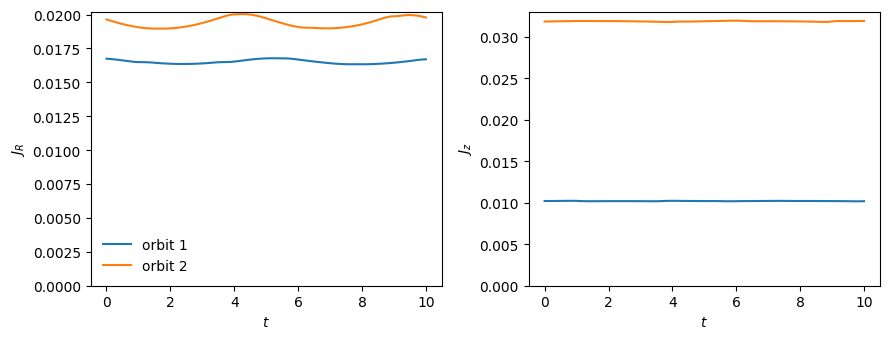

In [8]:
ts = numpy.linspace(0.0, 10.0, 101)


@jax.jit
def actions_along_orbit(ic):
    o = Orbit(ic)
    o.integrate(ts, MWPotential2014, method="diffrax")
    delta = estimateDeltaStaeckel(MWPotential2014, o.R(ts), o.z(ts))
    aAS = actionAngleStaeckel(pot=MWPotential2014, delta=delta, c=False)
    return delta, aAS(o.R(ts), o.vR(ts), o.vT(ts), o.z(ts), o.vz(ts))


start = time.perf_counter()
delta, (jr, lz, jz) = actions_along_orbit(jnp.array([1.0, 0.1, 1.1, 0.1, 0.05, 0.0]))
print(f"First call (compiles): {time.perf_counter() - start:.1f} s")
start = time.perf_counter()
delta2, (jr2, lz2, jz2) = actions_along_orbit(jnp.array([1.0, 0.2, 1.0, 0.2, 0.1, 0.0]))
print(f"Second call: {time.perf_counter() - start:.2f} s")
print(f"delta = {delta:.4f}, {delta2:.4f}")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 3.5))
ax1.plot(ts, jr, label="orbit 1")
ax1.plot(ts, jr2, label="orbit 2")
ax1.set_xlabel(r"$t$")
ax1.set_ylabel(r"$J_R$")
ax1.set_ylim(bottom=0.0)
ax1.legend(frameon=False)
ax2.plot(ts, jz)
ax2.plot(ts, jz2)
ax2.set_xlabel(r"$t$")
ax2.set_ylabel(r"$J_z$")
ax2.set_ylim(bottom=0.0)
fig.tight_layout()

The grid-based `actionAngleStaeckelGrid` builds its grid on the backend
and its interpolated actions are differentiable with respect to the
phase-space coordinates; when the potential has a parameter that is being
differentiated, it falls back to the exact method, with a warning.

## The adiabatic approximation

`actionAngleAdiabatic` follows the same pattern as `actionAngleStaeckel`:
the C implementation (`c=True`) attaches its Jacobian with respect to the
phase-space coordinates, and the Python implementation (`c=False`) is
differentiable throughout:

In [9]:
aAAc = actionAngleAdiabatic(pot=MWPotential2014, c=True)
print(jax.grad(lambda vz: aAAc(*wj[:4], vz)[2].sum())(wj[4]))
aAA = actionAngleAdiabatic(pot=MWPotential2014, c=False)
vzt = wt[4].clone().requires_grad_(True)
aAA(*wt[:4], vzt)[2].sum().backward()
print(vzt.grad)

[0.02294244 0.00973033 0.03889127]


tensor([0.0229, 0.0097, 0.0389], dtype=torch.float64)


## Spherical potentials

`actionAngleSpherical` computes the actions in any spherical potential by
root finding and quadrature, which on the backends are differentiable. For
the isochrone potential, the actions are also known in closed form
(`actionAngleIsochrone`), so we can compare the derivative of the radial
action with respect to the scale parameter $b$ of the potential computed in
both ways:

In [10]:
b = torch.tensor(0.8, dtype=torch.float64, requires_grad=True)
aASph = actionAngleSpherical(pot=IsochronePotential(amp=2.0, b=b))
aASph(*wt)[0].sum().backward()
print(b.grad)


def jr_isochrone(b):
    aAI = actionAngleIsochrone(ip=IsochronePotential(amp=2.0, b=b))
    return aAI(*wj)[0].sum()


print(jax.grad(jr_isochrone)(0.8))

tensor(2.9880, dtype=torch.float64)


2.9880352277847257


`actionAngleIsochrone` can also be set up with just the scale parameter,
`actionAngleIsochrone(b=...)`, for the isochrone potential with a circular
velocity of one at $R=1$; this is differentiable with respect to $b$ as
well, here compared with a finite difference:

In [11]:
def jr_isochrone_b(b):
    return actionAngleIsochrone(b=b)(*wj)[0].sum()


h = 1e-5
print(
    jax.grad(jr_isochrone_b)(0.8),
    (jr_isochrone_b(0.8 + h) - jr_isochrone_b(0.8 - h)) / (2.0 * h),
)

0.0048015829568963525 0.0048015829978709235


## The isochrone approximation

`actionAngleIsochroneApprox` integrates an auxiliary orbit; with
`integrate_method="diffrax"` it does so in JAX, and the actions are then
differentiable with respect to the parameters of the potential. For the
vertical action of an orbit in a flattened logarithmic halo as a function of
the flattening $q$:

In [12]:
w6 = [jnp.array([x]) for x in [1.0, 0.1, 0.7, 0.05, 0.05, 0.0]]  # R,vR,vT,z,vz,phi


def jz_of_q(q):
    aAI = actionAngleIsochroneApprox(
        pot=LogarithmicHaloPotential(normalize=1.0, q=q),
        b=0.8,
        integrate_method="diffrax",
    )
    return aAI(*w6)[2][0]


print(jax.jit(jax.grad(jz_of_q))(0.9))


def jz_of_q_numpy(q):
    aAI = actionAngleIsochroneApprox(
        pot=LogarithmicHaloPotential(normalize=1.0, q=q), b=0.8
    )
    return aAI(*[numpy.asarray(x) for x in w6])[2][0]


h = 1e-4
print((jz_of_q_numpy(0.9 + h) - jz_of_q_numpy(0.9 - h)) / (2.0 * h))

-0.000596688959621941
-0.0005965598306512977


The two differ at the $10^{-4}$ level because the NumPy version integrates
the auxiliary orbit with galpy's C integrator and the JAX version with
diffrax. Under PyTorch, `integrate_method="torchode"` or `"torchdiffeq"`
works as well, but is slow on a CPU.

## The inverse transformation: `actionAngleVerticalInverse`

`actionAngleVerticalInverse` computes positions and velocities from actions
and angles for one-dimensional potentials, by constructing a torus map for
a family of energies `Es`. A torus map that is set up on NumPy can be
evaluated at backend actions and angles:

In [13]:
Es = numpy.linspace(0.0, 1.0, 17)  # energies of the family of tori
disk = IsothermalDiskPotential(amp=1.0, sigma=0.5)
aAVI = actionAngleVerticalInverse(pot=disk, Es=Es, nta=128, setup_interp=True)
J = 0.06
angles = jnp.linspace(0.0, 2.0 * numpy.pi, 16, endpoint=False)
z, vz, Omega = aAVI.xvFreqs(J, angles)
print(type(z), Omega)

<class 'jaxlib._jax.ArrayImpl'> 3.2130816922583545


The construction (`setup_interp=True`) and the evaluation also run
natively on the backends, so the tori are differentiable with respect to the
action, the angle, and the parameters of the potential, through the
construction of the torus map. For a family of self-gravitating isothermal
disks parametrized by their velocity dispersion $\sigma$, we compute the
torus with action $J=0.06$ and its derivative with respect to $\sigma$ in
forward mode, compiled:

In [14]:
def torus(sigma):
    disk = IsothermalDiskPotential(amp=1.0, sigma=sigma)
    aAVI = actionAngleVerticalInverse(pot=disk, Es=Es, nta=128, setup_interp=True)
    return aAVI.xvFreqs(J, angles)[:2]  # (z, v_z)


start = time.perf_counter()
dz_dsigma, dvz_dsigma = jax.jit(jax.jacfwd(torus))(0.5)
print(f"{time.perf_counter() - start:.1f} s")

7.8 s


The derivative predicts the torus of a disk with a different velocity
dispersion. We compare the prediction with the torus of a rebuilt disk with
$\sigma=0.6$, at the same action and angles:

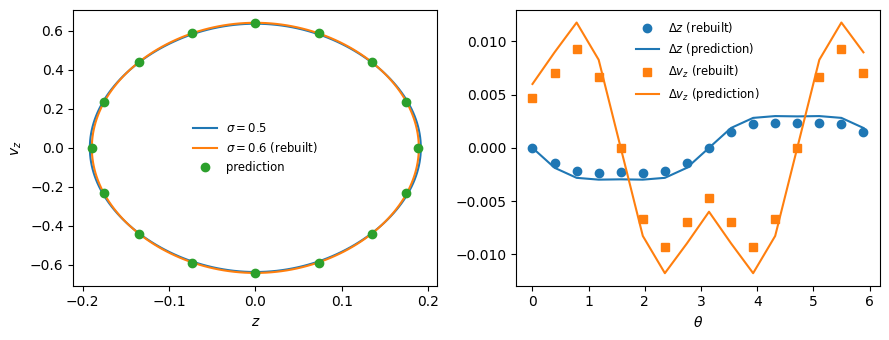

In [15]:
dsigma = 0.1
disk2 = IsothermalDiskPotential(amp=1.0, sigma=0.5 + dsigma)
aAVI2 = actionAngleVerticalInverse(pot=disk2, Es=Es, nta=128, setup_interp=True)
z2, vz2, _ = aAVI2.xvFreqs(J, angles)
angles_fine = numpy.linspace(0.0, 2.0 * numpy.pi, 201)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 3.5))
ax1.plot(*aAVI.xvFreqs(J, angles_fine)[:2], label=r"$\sigma=0.5$")
ax1.plot(*aAVI2.xvFreqs(J, angles_fine)[:2], label=r"$\sigma=0.6$ (rebuilt)")
ax1.plot(z + dsigma * dz_dsigma, vz + dsigma * dvz_dsigma, "o", label="prediction")
ax1.set_xlabel(r"$z$")
ax1.set_ylabel(r"$v_z$")
ax1.legend(frameon=False, fontsize="small")
ax2.plot(angles, z2 - z, "o", color="C0", label=r"$\Delta z$ (rebuilt)")
ax2.plot(angles, dsigma * dz_dsigma, "-", color="C0", label=r"$\Delta z$ (prediction)")
ax2.plot(angles, vz2 - vz, "s", color="C1", label=r"$\Delta v_z$ (rebuilt)")
ax2.plot(
    angles, dsigma * dvz_dsigma, "-", color="C1", label=r"$\Delta v_z$ (prediction)"
)
ax2.set_xlabel(r"$\theta$")
ax2.legend(frameon=False, fontsize="small")
fig.tight_layout()

The tori of `actionAngleVerticalInverse` can also be differentiated with
respect to the action and the angle, for example to obtain the Jacobian of
the transformation from $(J,\theta)$ to $(z,v_z)$. The older construction
modes of the class, which use point transformations, are evaluated natively
on the backends but built on NumPy, so they cannot be differentiated with
respect to the parameters of the potential.